In [134]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns


In [137]:
water_qual_raw = pd.read_csv('toronto-beaches-water-quality.csv')

In [138]:
water_qual = water_qual_raw[
    (~water_qual_raw['comments'].str.contains('sample', case=False, na=False)) & #eliminate rows with "no sample" cooments
    (water_qual_raw['eColi'] < 2000) # keep reasonable E. coli values
]

In [139]:
water_qual['collectionDate'] = pd.to_datetime(water_qual['collectionDate']) #collectionDate from objet to datetime

C:\Users\Caro Crespo\AppData\Local\Temp\ipykernel_2148\1623708602.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  water_qual['collectionDate'] = pd.to_datetime(water_qual['collectionDate']) #collectionDate from objet to datetime


In [140]:
water_qual['month_name'] = water_qual['collectionDate'].dt.strftime('%b') #identify the month of the sample
water_qual['year'] = water_qual['collectionDate'].dt.year #identify the year of the sample

C:\Users\Caro Crespo\AppData\Local\Temp\ipykernel_2148\1663226683.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  water_qual['month_name'] = water_qual['collectionDate'].dt.strftime('%b') #identify the month of the sample
C:\Users\Caro Crespo\AppData\Local\Temp\ipykernel_2148\1663226683.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  water_qual['year'] = water_qual['collectionDate'].dt.year #identify the year of the sample


In [141]:
daily_avg = water_qual.groupby(['collectionDate', 'beachName'])['eColi'].mean().reset_index() #mean eColi per day per beach

In [142]:
daily_avg['month'] = daily_avg['collectionDate'].dt.to_period('M').dt.to_timestamp() #dates grouped by month, and available for vsualizations

In [143]:
font1 = {'family':'Verdana','weight': 'bold','size':30}
font2 = {'family':'Arial', 'style':'italic', 'size':20}
font3 = {'family':'Arial', 'weight': 'bold', 'size':20}

Text(0.01, -0.05, 'Each dot represents the daily average E. coli level per beach. Stars indicate the monthly average E. coli level.')

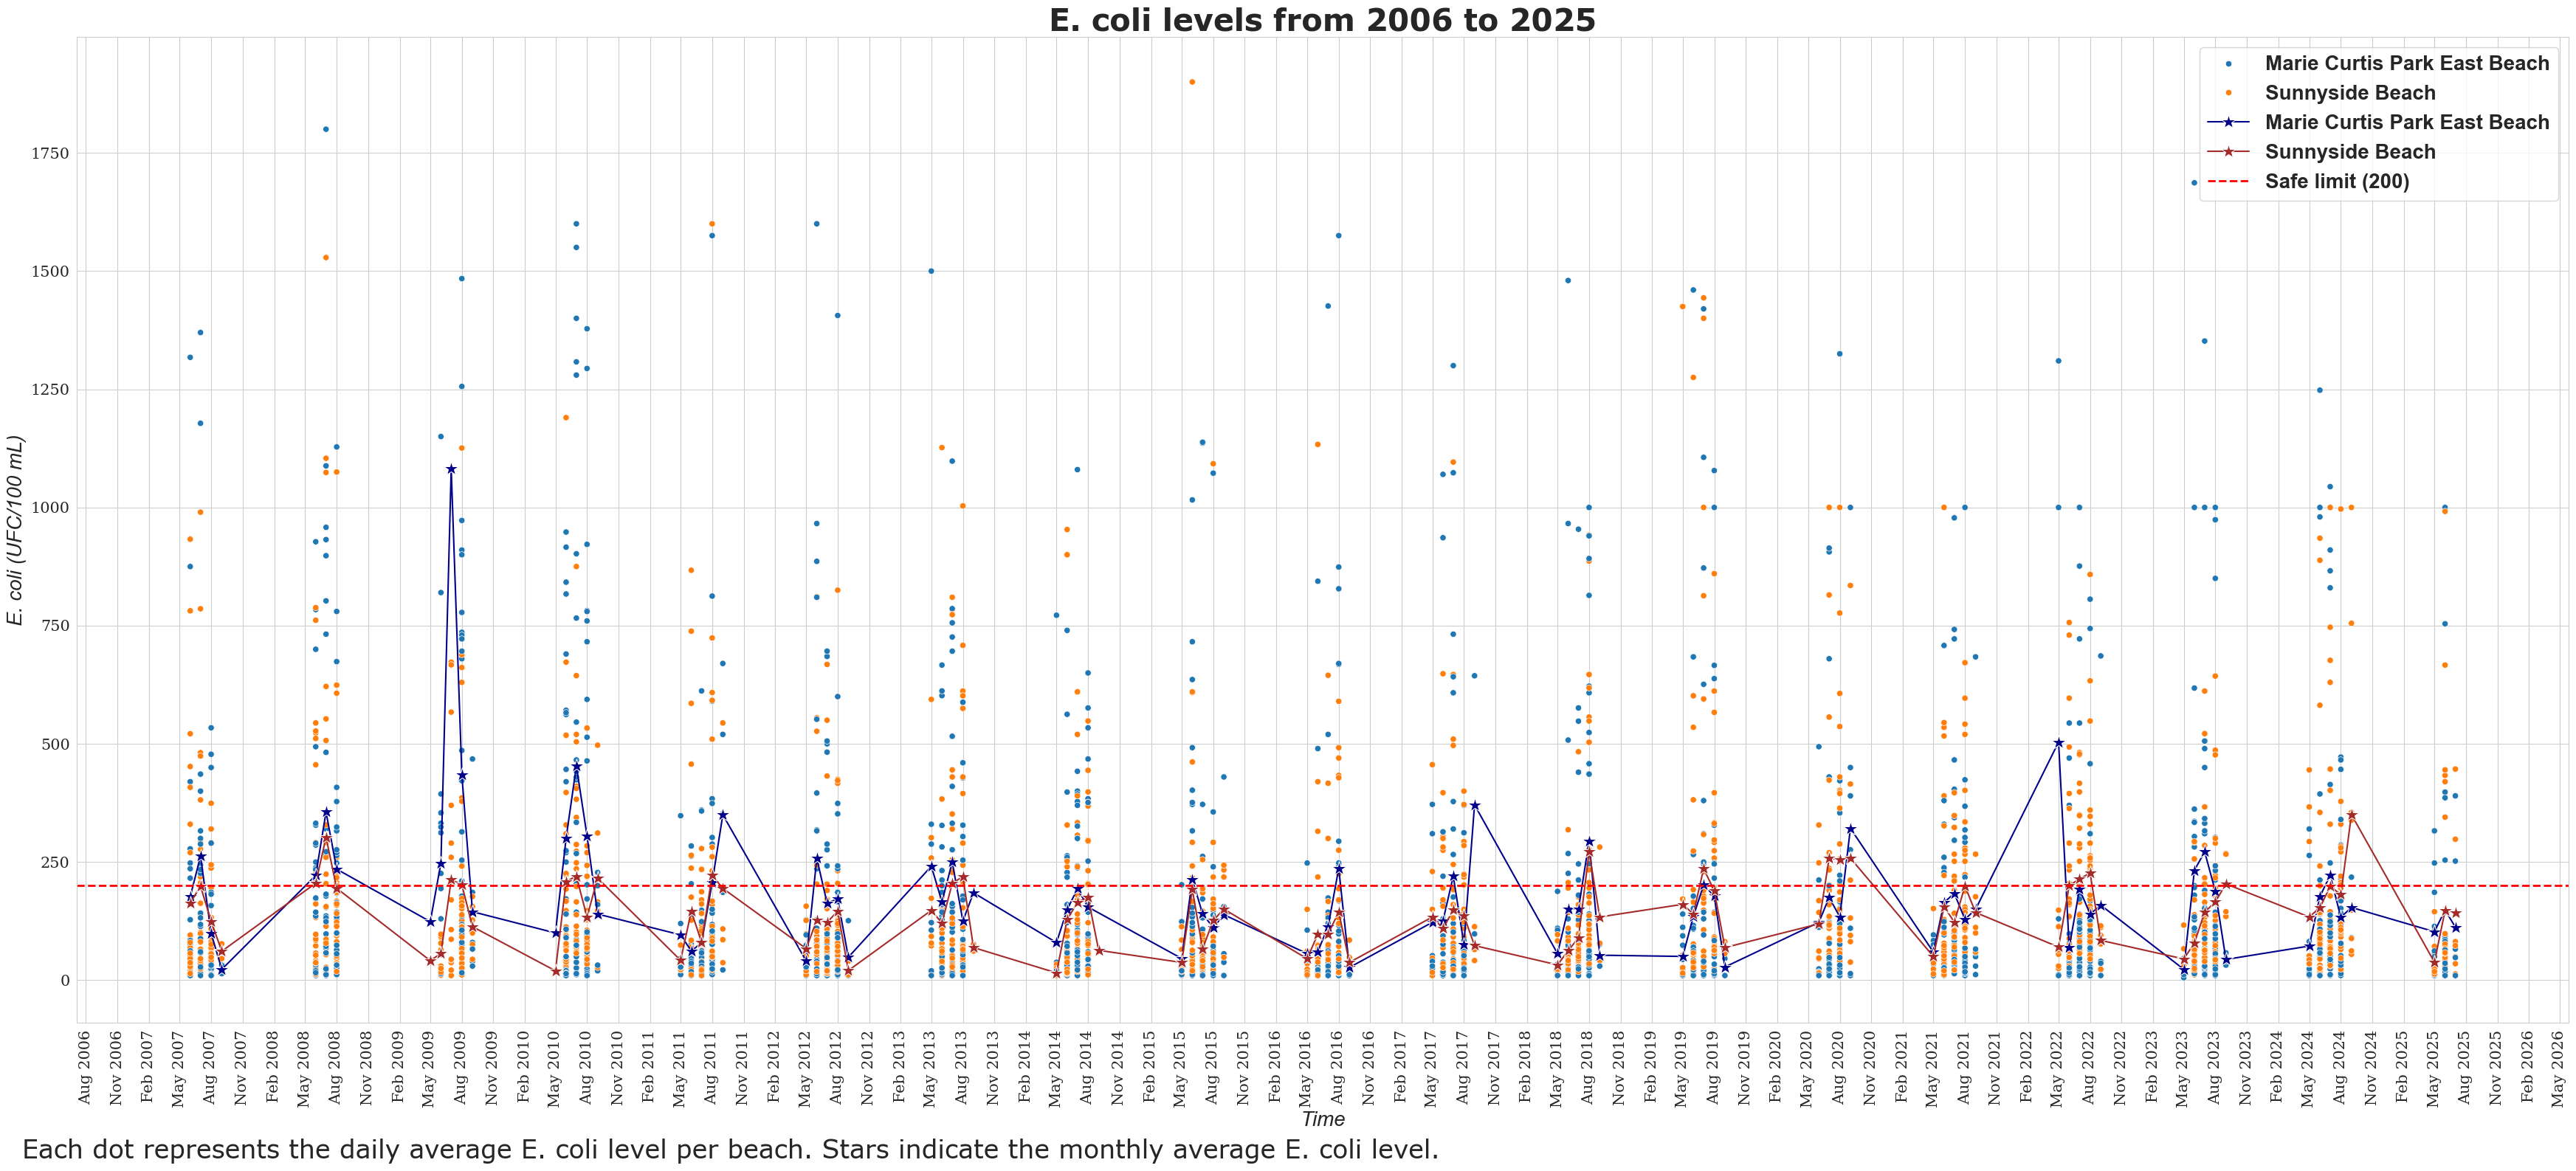

In [144]:
sns.set_style('whitegrid')
fig = plt.subplots (figsize = (35, 15))
sns.scatterplot(data=daily_avg, 
                x='month', 
                y='eColi', 
                hue='beachName')
sns.lineplot(data=daily_avg,
             x= 'month',
             y='eColi',
             hue='beachName',
             palette=['darkblue','brown'],
             errorbar=None,
             marker='*',
             markersize=15)
plt.xticks(fontsize=15, family='serif', rotation=90)
plt.yticks(fontsize=15, family='serif')
plt.title('E. coli levels from 2006 to 2025', fontdict=font1)
plt.ylabel('E. coli (UFC/100 mL)', fontdict=font2)
plt.xlabel('Time', fontdict=font2)
plt.axhline(y=200, color='red', linestyle='--', linewidth=2, label='Safe limit (200)')
plt.legend(prop=font3)
plt.tight_layout()
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.figtext(0.01, -0.05,
            "Each dot represents the daily average E. coli level per beach. "
            "Stars indicate the monthly average E. coli level.", 
            horizontalalignment='left', 
            fontsize=25, 
            fontfamily='Verdana')